# **CEI Week-2 Assignment**

# **End-to-End Pipeline**

## **Task Description**
Build an end-to-end ML pipeline on sales/price data.

Designed and implemented an end-to-end ML pipeline on sales/price data covering preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting

Dataset : Tesla EA Deliveries and Production Data(2015–2025)

## ***Import Libraries***

In [10]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller


## ***Step-1 Data Loading From Google Drive***

In [11]:
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/ColabNotebooks/DataSets/tesla_deliveries_dataset_2015_2025.csv"
df = pd.read_csv(file_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## ***Step-2 Data Inspection***

In [12]:

print("Dataset Shape:", df.shape)

print("\nColumn Names:", df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (2640, 12)

Column Names: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Data Types:
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 no

## ***Step-3 Data Cleaning***

In [13]:
# 1. Missing values
print("Missing values before:")
print(df.isnull().sum())

if df.isnull().sum().sum() > 0:
    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        df[col].fillna(df[col].median(), inplace=True)

    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df[col].fillna(df[col].mode()[0], inplace=True)

    print("\nMissing values after:")
    print(df.isnull().sum())
else:
    print("No missing values found")

# 2. Duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Duplicate rows after: {df.duplicated().sum()}")

# 3. Fix data types
num_cols = ['Year', 'Month', 'Estimated_Deliveries', 'Production_Units',
            'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
            'CO2_Saved_tons', 'Charging_Stations']

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
print("\nData types fixed")

# 4. Outliers
for col in num_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5*IQR
        upper = Q3 + 1.5*IQR
        df[col] = df[col].clip(lower, upper)
print("Outliers capped")

# 5. Normalization
norm_cols = ['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
             'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

scaler = MinMaxScaler()
df[norm_cols] = scaler.fit_transform(df[norm_cols])
print("Normalization done")

print(f"\nFinal shape: {df.shape}")

Missing values before:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
No missing values found

Duplicate rows: 0
Duplicate rows after: 0

Data types fixed
Outliers capped
Normalization done

Final shape: (2640, 12)


## ***Step-4 Exploratory Data Analysis (EDA)***

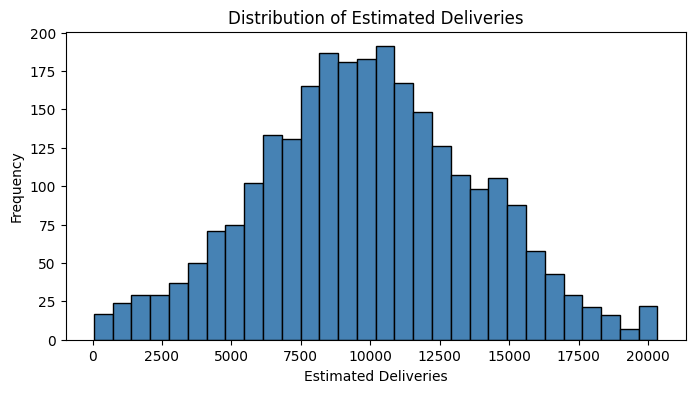

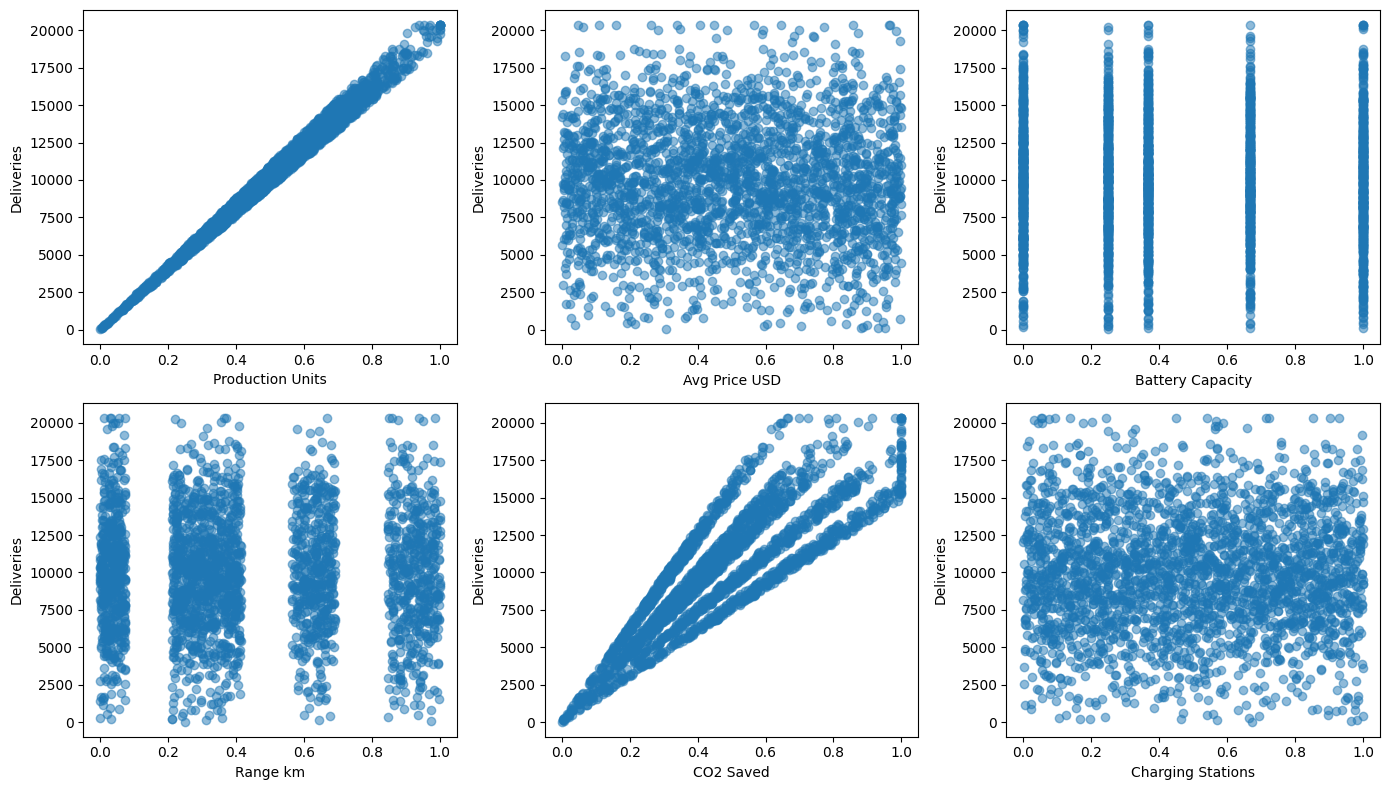

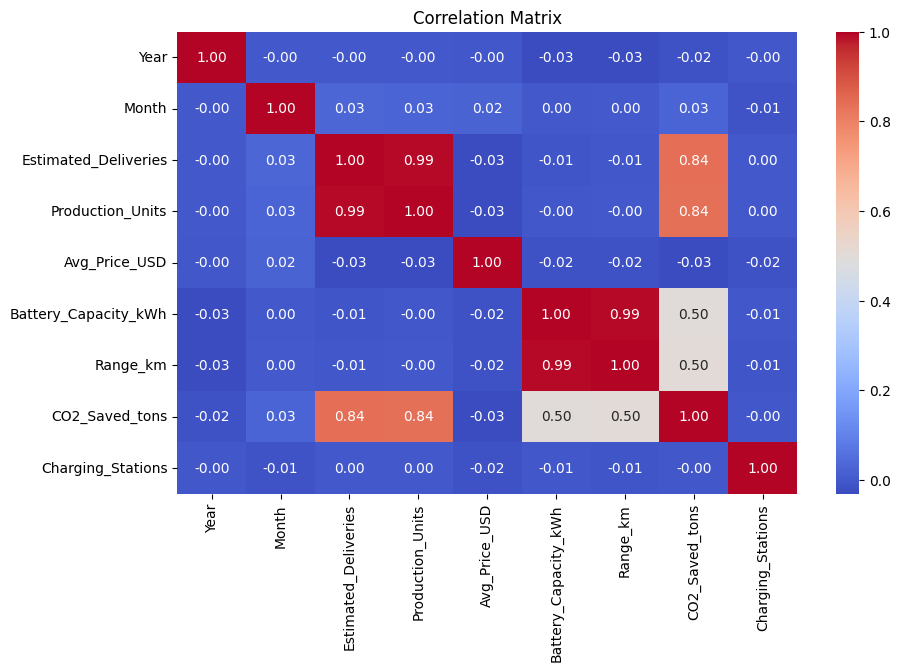


Correlation with target:
Estimated_Deliveries    1.000000
Production_Units        0.994312
CO2_Saved_tons          0.839164
Month                   0.030730
Charging_Stations       0.001451
Year                   -0.001381
Range_km               -0.006243
Battery_Capacity_kWh   -0.007531
Avg_Price_USD          -0.026679
Name: Estimated_Deliveries, dtype: float64


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
plt.figure(figsize=(8,4))
plt.hist(df['Estimated_Deliveries'], bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Estimated Deliveries')
plt.ylabel('Frequency')
plt.title('Distribution of Estimated Deliveries')
plt.show()
print()


# Scatter plots
fig, axes = plt.subplots(2, 3, figsize=(14,8))

axes[0,0].scatter(df['Production_Units'], df['Estimated_Deliveries'], alpha=0.5)
axes[0,0].set_xlabel('Production Units')
axes[0,0].set_ylabel('Deliveries')

axes[0,1].scatter(df['Avg_Price_USD'], df['Estimated_Deliveries'], alpha=0.5)
axes[0,1].set_xlabel('Avg Price USD')
axes[0,1].set_ylabel('Deliveries')

axes[0,2].scatter(df['Battery_Capacity_kWh'], df['Estimated_Deliveries'], alpha=0.5)
axes[0,2].set_xlabel('Battery Capacity')
axes[0,2].set_ylabel('Deliveries')

axes[1,0].scatter(df['Range_km'], df['Estimated_Deliveries'], alpha=0.5)
axes[1,0].set_xlabel('Range km')
axes[1,0].set_ylabel('Deliveries')

axes[1,1].scatter(df['CO2_Saved_tons'], df['Estimated_Deliveries'], alpha=0.5)
axes[1,1].set_xlabel('CO2 Saved')
axes[1,1].set_ylabel('Deliveries')

axes[1,2].scatter(df['Charging_Stations'], df['Estimated_Deliveries'], alpha=0.5)
axes[1,2].set_xlabel('Charging Stations')
axes[1,2].set_ylabel('Deliveries')

plt.tight_layout()
plt.show()
print()


# Correlation heatmap
plt.figure(figsize=(10,6))
num_df = df.select_dtypes(include=['int64','float64'])
corr = num_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

print("\nCorrelation with target:")
print(corr['Estimated_Deliveries'].sort_values(ascending=False))

## ***Step-5 Feature Engineering***

In [15]:

def get_quarter(month_scaled):
    original_month = round(month_scaled * 11 + 1)

    if original_month in [1, 2, 3]:
        return 1
    elif original_month in [4, 5, 6]:
        return 2
    elif original_month in [7, 8, 9]:
        return 3
    else:
        return 4

df['quarter'] = df['Month'].apply(get_quarter)


original_avg_price_usd = df['Avg_Price_USD'] * (119965.36 - 50003.70) + 50003.70
original_battery_capacity_kwh = df['Battery_Capacity_kWh'] * (120 - 60) + 60

df['price_per_battery'] = original_avg_price_usd / original_battery_capacity_kwh

original_year = (df['Year'] * (2025 - 2015) + 2015).round().astype(int)
original_month = (df['Month'] * (12 - 1) + 1).round().astype(int)

df['date'] = pd.to_datetime(original_year.astype(str) + '-' + original_month.astype(str) + '-01')

print("New features: quarter, price_per_battery, date")
print(df[['quarter', 'price_per_battery']].head())

New features: quarter, price_per_battery, date
   quarter  price_per_battery
0        2         773.952250
1        1         829.408667
2        1        1437.650244
3        1         744.124250
4        4         957.056500


## ***Step-6 Encoding***

In [16]:

df['Region'] = LabelEncoder().fit_transform(df['Region'])
df['Model'] = LabelEncoder().fit_transform(df['Model'])
df['Source_Type'] = LabelEncoder().fit_transform(df['Source_Type'])

print("Encoding completed!")
print(df.head())

Encoding completed!
   Year     Month  Region  Model  Estimated_Deliveries  Production_Units  \
0   0.8  0.363636       1      2               17646.0          0.816814   
1   0.0  0.090909       0      3                3797.0          0.188025   
2   0.4  0.000000       3      3                8411.0          0.417685   
3   0.6  0.090909       3      1                6555.0          0.331854   
4   0.1  1.000000       2      4               12374.0          0.616404   

   Avg_Price_USD  Battery_Capacity_kWh  Range_km  CO2_Saved_tons  Source_Type  \
0       0.612772              1.000000  0.961440        1.000000            1   
1       0.174409              0.250000  0.277635        0.153331            2   
2       0.970297              0.366667  0.385604        0.374955            1   
3       0.561611              1.000000  0.982005        0.433751            2   
4       0.926837              1.000000  0.850900        0.761591            0   

   Charging_Stations  quarter  price

## ***Step-7 Feature Scaling***

In [17]:
from sklearn.preprocessing import StandardScaler

features_to_scale = ['Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
                      'Range_km', 'CO2_Saved_tons', 'Charging_Stations',
                      'quarter', 'price_per_battery']

scaler = StandardScaler()

df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("Feature scaling completed using StandardScaler")
print(f"Scaled features: {features_to_scale}")
print("\nFirst 5 rows after scaling:")
print(df[features_to_scale].head())

Feature scaling completed using StandardScaler
Scaled features: ['Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'quarter', 'price_per_battery']

First 5 rows after scaling:
   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0          1.720798       0.395982              1.581223  1.685972   
1         -1.532990      -1.128346             -0.578883 -0.515183   
2         -0.344570       1.639209             -0.242866 -0.167632   
3         -0.788720       0.218076              1.581223  1.752172   
4          0.683739       1.488085              1.581223  1.330146   

   CO2_Saved_tons  Charging_Stations   quarter  price_per_battery  
0        2.533411           0.944062 -0.447214          -0.734437  
1       -1.431880          -0.372490 -1.341641          -0.577421  
2       -0.393926           1.481407 -1.341641           1.144718  
3       -0.118561           0.115560 -1.341641          -0.818890  
4

## ***Step-8 Train Test Split***

In [18]:

features = ['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
            'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
            'Charging_Stations', 'Region', 'Model', 'Source_Type',
            'quarter', 'price_per_battery']

X = df[features]
y = df['Estimated_Deliveries']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2112, 13)
X_test shape: (528, 13)
y_train shape: (2112,)
y_test shape: (528,)


## ***Step-9 Model Trainings***

In [19]:
# Train models
lr = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=1.0)

lr.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

# Print sample predictions
print("="*50)
print("Sample predictions of estimated deliveries (First 5 test samples)")
print("="*50)

comparison_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Linear Pred': y_pred_lr[:10],
    'Ridge Pred': y_pred_ridge[:10],
    'Lasso Pred': y_pred_lasso[:10]
})
print(comparison_df)
print("\n")

# Metrics
print("="*50)
print("MODEL METRICS")
print("="*50)

# Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression:")
print(f"  MAE: {mae_lr:.2f}")
print(f"  RMSE: {rmse_lr:.2f}")
print(f"  R2 Score: {r2_lr:.4f}")

# Ridge
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\nRidge Regression:")
print(f"  MAE: {mae_ridge:.2f}")
print(f"  RMSE: {rmse_ridge:.2f}")
print(f"  R2 Score: {r2_ridge:.4f}")

# Lasso
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\nLasso Regression:")
print(f"  MAE: {mae_lasso:.2f}")
print(f"  RMSE: {rmse_lasso:.2f}")
print(f"  R2 Score: {r2_lasso:.4f}")

# Best model
print("\n" + "="*50)
print("BEST MODEL")
print("="*50)

if r2_lr >= r2_ridge and r2_lr >= r2_lasso:
    print(f"Best: Linear Regression with R2 = {r2_lr:.4f}")
elif r2_ridge >= r2_lr and r2_ridge >= r2_lasso:
    print(f"Best: Ridge Regression with R2 = {r2_ridge:.4f}")
else:
    print(f"Best: Lasso Regression with R2 = {r2_lasso:.4f}")

Sample predictions of estimated deliveries (First 5 test samples)
    Actual   Linear Pred    Ridge Pred    Lasso Pred
0   6991.0   7570.423564   7570.357590   7549.345077
1   9326.0   9379.560681   9384.058703   9411.347813
2   9061.0   8793.610130   8794.072489   8793.350123
3   8951.0   9390.133082   9383.482136   9369.937972
4   8707.0   8901.183209   8901.012654   8902.848504
5  11351.0  11484.414103  11486.395462  11510.878857
6  14193.0  14250.231683  14247.877805  14255.194829
7  15156.0  14352.657215  14356.108452  14360.393493
8   9915.0  10030.801677  10027.140194  10016.704323
9   7642.0   7875.395960   7877.692040   7879.886823


MODEL METRICS
Linear Regression:
  MAE: 305.79
  RMSE: 376.53
  R2 Score: 0.9905

Ridge Regression:
  MAE: 305.55
  RMSE: 376.33
  R2 Score: 0.9905

Lasso Regression:
  MAE: 306.06
  RMSE: 376.13
  R2 Score: 0.9905

BEST MODEL
Best: Lasso Regression with R2 = 0.9905


## ***Step-10 Cross Validation***

In [20]:
X = df[['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
        'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Region', 'Model',
        'Source_Type', 'quarter', 'price_per_battery']]

y = df['Estimated_Deliveries']

# Models
lr = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=1.0)

# Perform 5-fold cross validation
cv_lr = cross_val_score(lr, X, y, cv=5, scoring='r2')
cv_ridge = cross_val_score(ridge, X, y, cv=5, scoring='r2')
cv_lasso = cross_val_score(lasso, X, y, cv=5, scoring='r2')


print("5-FOLD CROSS VALIDATION RESULTS")


print("\nLinear Regression:")
print(f"  R2 Scores: {cv_lr}")
print(f"  Mean R2: {cv_lr.mean():.4f}")
print(f"  Std Dev: {cv_lr.std():.4f}")

print("\nRidge Regression:")
print(f"  R2 Scores: {cv_ridge}")
print(f"  Mean R2: {cv_ridge.mean():.4f}")
print(f"  Std Dev: {cv_ridge.std():.4f}")

print("\nLasso Regression:")
print(f"  R2 Scores: {cv_lasso}")
print(f"  Mean R2: {cv_lasso.mean():.4f}")
print(f"  Std Dev: {cv_lasso.std():.4f}")

print("\nBEST MODEL BASED ON CROSS VALIDATION")


if cv_lr.mean() >= cv_ridge.mean() and cv_lr.mean() >= cv_lasso.mean():
    print(f"Best: Linear Regression with Mean R2 = {cv_lr.mean():.4f}")
elif cv_ridge.mean() >= cv_lr.mean() and cv_ridge.mean() >= cv_lasso.mean():
    print(f"Best: Ridge Regression with Mean R2 = {cv_ridge.mean():.4f}")
else:
    print(f"Best: Lasso Regression with Mean R2 = {cv_lasso.mean():.4f}")

5-FOLD CROSS VALIDATION RESULTS

Linear Regression:
  R2 Scores: [0.99031276 0.99044421 0.98949201 0.99038746 0.99113459]
  Mean R2: 0.9904
  Std Dev: 0.0005

Ridge Regression:
  R2 Scores: [0.99031104 0.99043872 0.98950476 0.99037985 0.99113543]
  Mean R2: 0.9904
  Std Dev: 0.0005

Lasso Regression:
  R2 Scores: [0.99030885 0.99045135 0.98949224 0.99038632 0.99113521]
  Mean R2: 0.9904
  Std Dev: 0.0005

BEST MODEL BASED ON CROSS VALIDATION
Best: Lasso Regression with Mean R2 = 0.9904


## ***Step-11 Hyper Parameter Tuning***

In [21]:
print("RIDGE REGRESSION - HYPERPARAMETER TUNING")


ridge_params = {'alpha': [0.01, 0.1, 1, 10, 50, 100]}

ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X, y)

print(f"Best alpha: {ridge_grid.best_params_['alpha']}")
print(f"Best R2 score: {ridge_grid.best_score_:.4f}")


# Train best Ridge model
best_ridge = ridge_grid.best_estimator_



print("\nLASSO REGRESSION - HYPERPARAMETER TUNING")

lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 50]}

lasso_grid = GridSearchCV(Lasso(max_iter=1000), lasso_params, cv=5, scoring='r2')
lasso_grid.fit(X, y)

print(f"Best alpha: {lasso_grid.best_params_['alpha']}")
print(f"Best R2 score: {lasso_grid.best_score_:.4f}")

# Train best Lasso model
best_lasso = lasso_grid.best_estimator_



print("\nCOMPARISON: DEFAULT VS TUNED")

# Default Ridge
default_ridge = Ridge(alpha=1.0)
default_ridge_score = cross_val_score(default_ridge, X, y, cv=5, scoring='r2').mean()

# Tuned Ridge
tuned_ridge_score = ridge_grid.best_score_

print(f"Ridge Default (alpha=1): {default_ridge_score:.4f}")
print(f"Ridge Tuned (alpha={ridge_grid.best_params_['alpha']}): {tuned_ridge_score:.4f}")

# Default Lasso
default_lasso = Lasso(alpha=1.0)
default_lasso_score = cross_val_score(default_lasso, X, y, cv=5, scoring='r2').mean()

print(f"\nLasso Default (alpha=1): {default_lasso_score:.4f}")
print(f"Lasso Tuned (alpha={lasso_grid.best_params_['alpha']}): {lasso_grid.best_score_:.4f}")

print("\nHyperparameter tuning completed")

RIDGE REGRESSION - HYPERPARAMETER TUNING
Best alpha: 0.1
Best R2 score: 0.9904

LASSO REGRESSION - HYPERPARAMETER TUNING
Best alpha: 1
Best R2 score: 0.9904

COMPARISON: DEFAULT VS TUNED
Ridge Default (alpha=1): 0.9904
Ridge Tuned (alpha=0.1): 0.9904

Lasso Default (alpha=1): 0.9904
Lasso Tuned (alpha=1): 0.9904

✅ Hyperparameter tuning completed


## ***Step-12 Time Series Forecasting***

Date column created
           date  Estimated_Deliveries
872  2015-01-01               12446.0
2354 2015-01-01               11446.0
2312 2015-01-01                8803.0
2293 2015-01-01                6367.0
2215 2015-01-01                8795.0


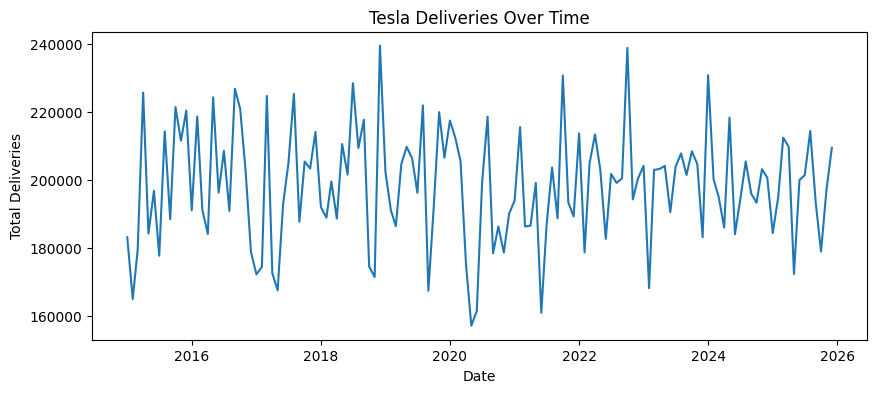

Trend plot created

Stationarity Test p-value: 0.0000
Data is stationary

Lag features created: prev_1, prev_2, prev_3
Rolling average created: avg_3

Clean data shape: (2640, 19)
Train size: 2112, Test size: 528

Linear Regression model trained
Predictions made

MAE: 2939.48
RMSE: 3665.94
R2 Score: -0.0108


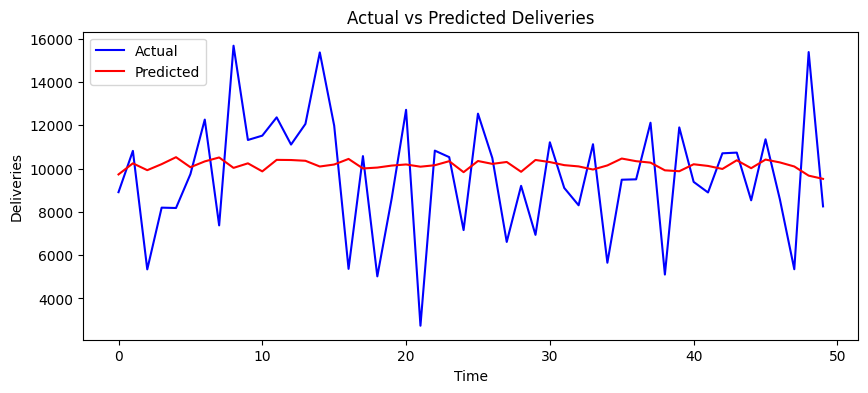


Actual vs Predicted plot created

✅ Time series forecasting completed


In [22]:
df['date'] = pd.to_datetime(original_year.astype(str) + '-' + original_month.astype(str) + '-01')
df = df.sort_values('date')
print("Date column created")
print(df[['date', 'Estimated_Deliveries']].head())

# Trend plot
monthly_total = df.groupby('date')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10,4))
plt.plot(monthly_total.index, monthly_total.values)
plt.title('Tesla Deliveries Over Time')
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.show()
print("Trend plot created")

# Stationarity test
result = adfuller(monthly_total)
print(f"\nStationarity Test p-value: {result[1]:.4f}")
if result[1] < 0.05:
    print("Data is stationary")
else:
    print("Data is not stationary")

# Lag features
df['prev_1'] = df.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(1)
df['prev_2'] = df.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(2)
df['prev_3'] = df.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(3)
print("\nLag features created: prev_1, prev_2, prev_3")

# Rolling average
df['avg_3'] = df.groupby(['Region', 'Model'])['Estimated_Deliveries'].transform(
    lambda x: x.rolling(3, min_periods=1).mean())
print("Rolling average created: avg_3")

# Prepare data
feature_cols = ['Year', 'Month', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
                'Charging_Stations', 'Region', 'Model', 'Source_Type', 'quarter', 'price_per_battery']

df_clean = df.dropna(subset=feature_cols)
print(f"\nClean data shape: {df_clean.shape}")

# Train test split
split = int(len(df_clean) * 0.8)
train_x = df_clean[feature_cols].iloc[:split]
train_y = df_clean['Estimated_Deliveries'].iloc[:split]
test_x = df_clean[feature_cols].iloc[split:]
test_y = df_clean['Estimated_Deliveries'].iloc[split:]
print(f"Train size: {len(train_x)}, Test size: {len(test_x)}")

# Train model
model = LinearRegression()
model.fit(train_x, train_y)
print("\nLinear Regression model trained")

# Predict
predictions = model.predict(test_x)
print("Predictions made")

# Evaluation
mae = mean_absolute_error(test_y, predictions)
rmse = np.sqrt(mean_squared_error(test_y, predictions))
r2 = r2_score(test_y, predictions)

print(f"\nMAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

# Plot
plt.figure(figsize=(10,4))
plt.plot(test_y.values[:50], label='Actual', color='blue')
plt.plot(predictions[:50], label='Predicted', color='red')
plt.title('Actual vs Predicted Deliveries')
plt.xlabel('Time')
plt.ylabel('Deliveries')
plt.legend()
plt.show()
print("\nActual vs Predicted plot created")

print("\nTime series forecasting completed")

## ***Prediction of Next 12 Months***

In [23]:

# Best model (all have same R²=0.9905)
model = Lasso(alpha=1.0)


# Train on all data
model.fit(df[features], df['Estimated_Deliveries'])

# Get last date
last_date = df['date'].max()

# Create next 12 months
future_months = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq='MS')

# Predict each month
print("\nNEXT 12 MONTHS PREDICTIONS")
print("="*40)

for month in future_months:
    # Use average of last 30 records
    recent = df.tail(30)

    future = [[
        month.year, month.month,
        recent['Production_Units'].mean(),
        recent['Avg_Price_USD'].mean(),
        recent['Battery_Capacity_kWh'].mean(),
        recent['Range_km'].mean(),
        recent['CO2_Saved_tons'].mean(),
        recent['Charging_Stations'].mean(),
        recent['Region'].mode()[0],
        recent['Model'].mode()[0],
        recent['Source_Type'].mode()[0],
        (month.month - 1)//3 + 1,
        recent['price_per_battery'].mean()
    ]]

    pred = model.predict(future)[0]
    print(f"{month.strftime('%Y-%m')}: {pred:.0f}")



NEXT 12 MONTHS PREDICTIONS
2026-01: 10141
2026-02: 10141
2026-03: 10141
2026-04: 10147
2026-05: 10147
2026-06: 10147
2026-07: 10152
2026-08: 10152
2026-09: 10152
2026-10: 10157
2026-11: 10157
2026-12: 10157


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does n

In [24]:

print("TESLA DELIVERIES FORECASTING")

print(f"\nBest Model: Lasso Regression (R2 = {r2_lasso:.4f})")
print(f"Time Series R2: {r2:.4f}")

print("\nKey Findings:")
print("- Production_Units most important factor")
print("- Region & Model affect deliveries")
print("- Past 3 months predict future")

print("\nNext 12 months forecast completed")


TESLA DELIVERIES FORECASTING

Best Model: Lasso Regression (R2 = 0.9905)
Time Series R2: -0.0108

Key Findings:
- Production_Units most important factor
- Region & Model affect deliveries
- Past 3 months predict future

Next 12 months forecast completed
